In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import INV_PATH, TP2_PATH

ABS_PATH = PROJECT_ROOT + INV_PATH + TP2_PATH
LOAD_MSH = PROJECT_ROOT

model_name = "column"
xdmf_file_name = "column.xdmf"

# Nome figure
fig_dir = "figures/"
eig_fig = ABS_PATH + fig_dir + "sv.png"
error_fig = ABS_PATH + fig_dir + "error.png"
speed_up_fig = ABS_PATH + fig_dir + "speed_up.png"
samples_fig = ABS_PATH + fig_dir + "samples.png"

dbdir = ABS_PATH + "database/"

In [3]:
import fenics as fe

from fem_problems.invTP2.finite_element import SystemParabolicFEM
from fem_problems.invTP2.rbnics_pod_temp import TemporalPOD

[michael-Alienware-Aurora-R15:3169851] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.michael-Alienware-Aurora-R15.1001/jf.0/2216820736/shared_mem_cuda_pool.michael-Alienware-Aurora-R15 could be created.
[michael-Alienware-Aurora-R15:3169851] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


Carichiamo la mesh

In [4]:
# Path to the XDMF file
file_path = ABS_PATH + xdmf_file_name

# Carica la mesh da file XDMF
mesh = fe.Mesh()
with fe.XDMFFile(file_path) as infile:
    infile.read(mesh)

Definiamo il range dei parametri

In [5]:
mu_range = [
    (0, 1.),
    (0, 1.),
    (0, 1.),
]

Definiamo il problema fem e il pod

In [6]:
temporal_steps = 21
time_interval = [0, 1]

fem_p = SystemParabolicFEM(mesh, time_interval, temporal_steps)
pod = TemporalPOD(mu_range, fem_p)

In [7]:
num_training = 20
num_testing = 5

N_modes = num_training*fem_p.temp_points
tol = 1e-6

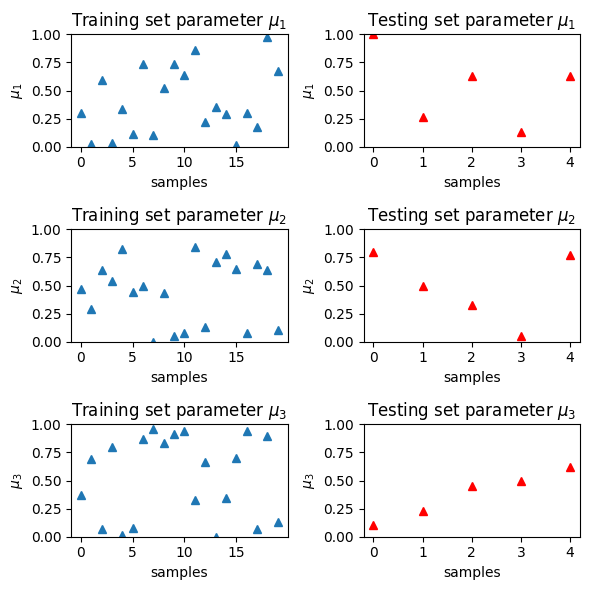

In [8]:
training = pod.sampling_parameters(num_training)
testing = pod.sampling_parameters(num_testing, test=True)
pod.plot_samples(figsize = (6, 6), filename=samples_fig)

In [9]:
pod.pod_execution(N_modes, tol)

STORING SNAPSHOTS...
+++ Compute and store temporal snaphot 1 for mu = [0.30292828 0.46768007 0.36959783] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 1
+++ Compute and store temporal snaphot 2 for mu = [0.02625062 0.28886466 0.69099099] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 2
+++ Compute and store temporal snaphot 3 for mu = [0.59110077 0.63708973 0.06517139] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 3
+++ Compute and store temporal snaphot 4 for mu = [0.03002793 0.53692487 0.79962894] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 4
+++ Compute and store temporal snaphot 5 for mu = [0.33400349 0.82634089 0.01448307] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 5
+++ Compute and store temporal snaphot 6 for mu = [0.11526935 0.44616845 0.0736361 ] +++
STORING TEMPORAL SNAPSHOT
... End of compute and store temporal snaphot 6
+

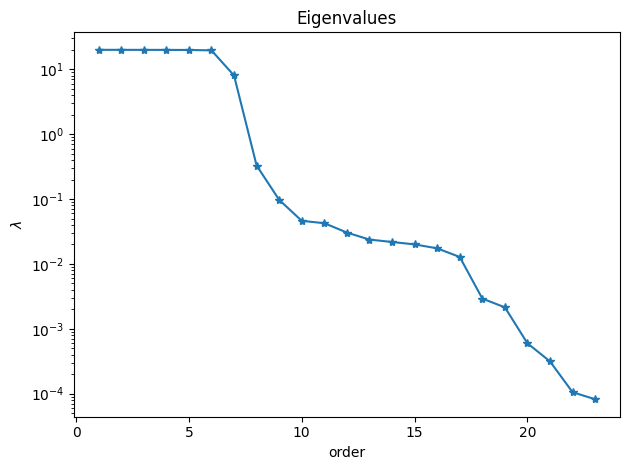

In [10]:
pod.plot_eigenvalues(filename=eig_fig)

In [11]:
pod.store_reduction(directory=dbdir, filename=model_name)

Start STORING REDUCTION......End STORING REDUCTION


In [12]:
mu_test = [.2, .6, .4]
mat, _ = pod.solve_rom(mu_test, pod.num_basis)
fom_m, _ = pod.fem_p.solve_fem(mu_test)
real_m, _ = pod.fem_p.exact_solution(mu_test)

print("ERRORE FOM-ESATTA")
e, f = pod.fem_p.compute_error(fom_m, real_m)
print("ERRORE ROM-FOM")
a, b = pod.fem_p.compute_error(mat, fom_m)
print("ERRORE ROM-ESATTA")
c, d = pod.fem_p.compute_error(mat, real_m)

ERRORE FOM-ESATTA
ERRORI EQUAZIONE 1
Errore Assoluto: 3.2716e+00
Errore Relativo: 2.1192e-02
ERRORI EQUAZIONE 2
Errore Assoluto: 2.3353e+00
Errore Relativo: 9.8481e-03
ERRORE ROM-FOM
ERRORI EQUAZIONE 1
Errore Assoluto: 6.9731e-04
Errore Relativo: 4.5172e-06
ERRORI EQUAZIONE 2
Errore Assoluto: 7.3444e-04
Errore Relativo: 3.0980e-06
ERRORE ROM-ESATTA
ERRORI EQUAZIONE 1
Errore Assoluto: 3.2718e+00
Errore Relativo: 2.1193e-02
ERRORI EQUAZIONE 2
Errore Assoluto: 2.3353e+00
Errore Relativo: 9.8481e-03


In [13]:
error, _ = pod.error_analysis()


=============== POD basis number N = 1 ===============
Solve for test parameter i = 0, mu=[0.99978287 0.79908555 0.1067159 ]
Solve for test parameter i = 1, mu=[0.26095221 0.49213722 0.23069627]
Solve for test parameter i = 2, mu=[0.63329851 0.32253519 0.4507214 ]
Solve for test parameter i = 3, mu=[0.12951114 0.05017036 0.49721909]
Solve for test parameter i = 4, mu=[0.63131557 0.77447249 0.61669524]

=============== POD basis number N = 2 ===============
Solve for test parameter i = 0, mu=[0.99978287 0.79908555 0.1067159 ]
Solve for test parameter i = 1, mu=[0.26095221 0.49213722 0.23069627]
Solve for test parameter i = 2, mu=[0.63329851 0.32253519 0.4507214 ]
Solve for test parameter i = 3, mu=[0.12951114 0.05017036 0.49721909]
Solve for test parameter i = 4, mu=[0.63131557 0.77447249 0.61669524]

=============== POD basis number N = 3 ===============
Solve for test parameter i = 0, mu=[0.99978287 0.79908555 0.1067159 ]
Solve for test parameter i = 1, mu=[0.26095221 0.49213722 0.23

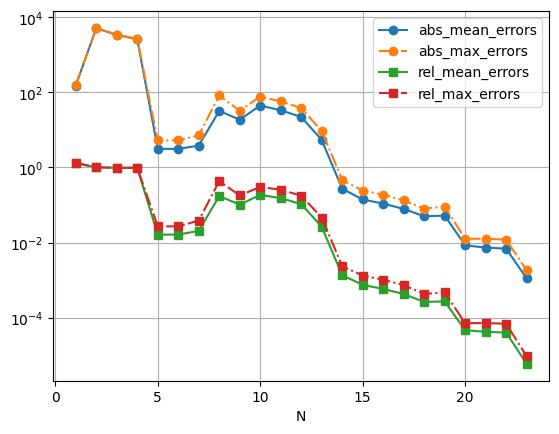

In [14]:
pod.plot_errors(error, filename=error_fig)

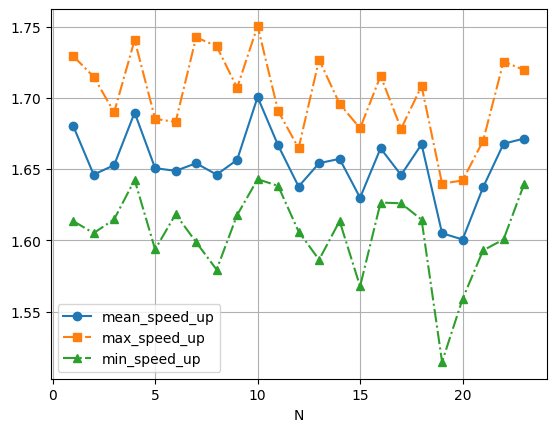

In [15]:
pod.plot_speed_up(error, filename=speed_up_fig)

In [16]:
pod.save_table_error(error)

In [17]:
pod.table_error(error)

Solution errors:
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   N |   mean(error_u) |   max(error_u) |   mean(relative_error_u) |   max(relative_error_u) |   speed_up |
+=====+=================+================+==========================+=========================+============+
|   1 |    152.101      |   156.478      |              1.31398     |             1.32947     |    1.68039 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   2 |   5128.92       |  5214.7        |              1.00989     |             1.0101      |    1.64615 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   3 |   3379.72       |  3436.75       |              0.979557    |             0.980056    |    1.65276 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
| 